In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("50_Startups.csv")

In [3]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
dataset=pd.get_dummies(dataset,drop_first=True).astype(int)

In [5]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349,136897,471784,192261,0,1
1,162597,151377,443898,191792,0,0
2,153441,101145,407934,191050,1,0
3,144372,118671,383199,182901,0,1
4,142107,91391,366168,166187,1,0
5,131876,99814,362861,156991,0,1
6,134615,147198,127716,156122,0,0
7,130298,145530,323876,155752,1,0
8,120542,148718,311613,152211,0,1
9,123334,108679,304981,149759,0,0


In [6]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [7]:
indep=dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York' ]]
dep=dataset[[ 'Profit']]


In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(indep,dep,test_size=0.30,random_state=0)

In [9]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion="absolute_error",splitter="best",max_features=1,max_leaf_nodes=2)
regressor.fit(X_train,y_train)

DecisionTreeRegressor(criterion='absolute_error', max_features=1,
                      max_leaf_nodes=2)

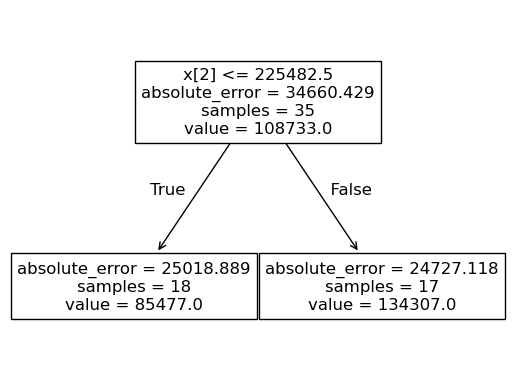

In [10]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [11]:
y_pred=regressor.predict(X_test)

In [12]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)

In [13]:
r_score

0.4936501300752787